In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_excel("../data/Telco_customer_churn.xlsx")

df.shape

(7043, 33)

In [27]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

df["Total Charges"] = df["Total Charges"].fillna(
    df["Total Charges"].median()
)

In [42]:
y = df["Churn Value"]

In [43]:
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "Lat Long",
    "Churn Value",
    "Churn Label",
    "Churn Score",
    "Churn Reason"
]

X = df.drop(columns=drop_columns)
X.shape

(7043, 24)

In [44]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical:", len(categorical_features))
print("Numerical:", len(numerical_features))

Categorical: 17
Numerical: 7


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [47]:
print(categorical_features)
print(numerical_features)

['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']


In [48]:
X_train_processed = preprocessor.fit_transform(X_train)

print(X_train_processed.shape)

(5634, 1178)


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)

In [50]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [51]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Zip Code', 'Latitude',
                                                   'Longitude', 'Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges', 'CLTV']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['City', 'Gender',
                                                   'Senior Citizen', 'Partner',
                                                   'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [53]:
preds = model.predict(X_test)

probs = model.predict_proba(X_test)[:,1]

In [54]:
print("Accuracy:", accuracy_score(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

Accuracy: 0.7913413768630234
ROC-AUC: 0.840148285928337


In [55]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)
print(cm)

[[908 127]
 [167 207]]


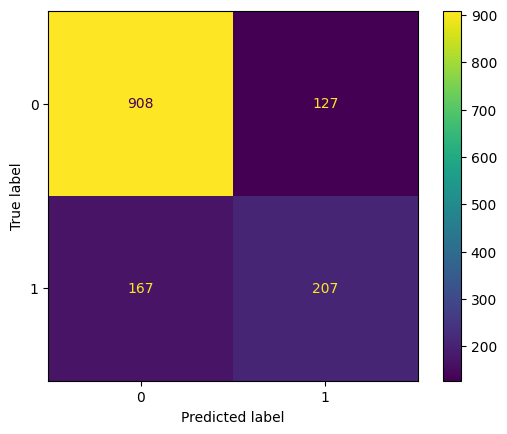

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, preds)

plt.show()

In [59]:
from xgboost import XGBClassifier

/home/msibex/customer-churn-prediction/.venv/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [60]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    )
])

In [61]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Zip Code', 'Latitude',
                                                   'Longitude', 'Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges', 'CLTV']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['City', 'Gender',
                                                   'Senior Citizen', 'Partner',
                                                   'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Onl...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [62]:
xgb_preds = xgb_model.predict(X_test)

xgb_probs = xgb_model.predict_proba(X_test)[:,1]

In [63]:
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print("ROC-AUC:", roc_auc_score(y_test, xgb_probs))

Accuracy: 0.7735982966643009
ROC-AUC: 0.8285308326229043


## Model Selection

Two models were evaluated:

| Model | Accuracy | ROC-AUC |
|---------|---------|---------|
| Logistic Regression | 0.791 | 0.840 |
| XGBoost | 0.774 | 0.829 |

Logistic Regression achieved superior performance on the test set and was selected as the final model for interpretation and deployment.

In [65]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficients = model.named_steps["classifier"].coef_[0]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance.sort_values(
    by="Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient
948,cat__City_Smith River,1.699388
860,cat__City_Running Springs,1.547386
306,cat__City_Elk Grove,1.436353
876,cat__City_San Dimas,1.407170
926,cat__City_Seeley,1.330100
309,cat__City_Emeryville,1.309823
782,cat__City_Piru,1.240774
1035,cat__City_Tujunga,1.234878
241,cat__City_Crockett,1.199954
515,cat__City_Lake City,1.130775


In [66]:
importance.sort_values(
    by="Coefficient",
    ascending=True
).head(15)

,Feature,Coefficient
3,num__Tenure Months,-1.257813
63,cat__City_Bakersfield,-1.177161
30,cat__City_Anaheim,-1.102063
911,cat__City_Santa Maria,-1.049987
51,cat__City_Atascadero,-1.043535
1048,cat__City_Upland,-1.023879
368,cat__City_Gardena,-1.001848
84,cat__City_Beverly Hills,-0.984458
27,cat__City_Alviso,-0.978103
886,cat__City_San Juan Capistrano,-0.961141


In [67]:
X_test_processed = model.named_steps["preprocessor"].transform(X_test)

feature_names = (
    model.named_steps["preprocessor"]
    .get_feature_names_out()
)

In [68]:
import shap
explainer = shap.LinearExplainer(
    model.named_steps["classifier"],
    X_test_processed
)

In [69]:
shap_values = explainer(X_test_processed)

In [71]:
X_test_dense = pd.DataFrame(
    X_test_processed.toarray(),
    columns=feature_names
)

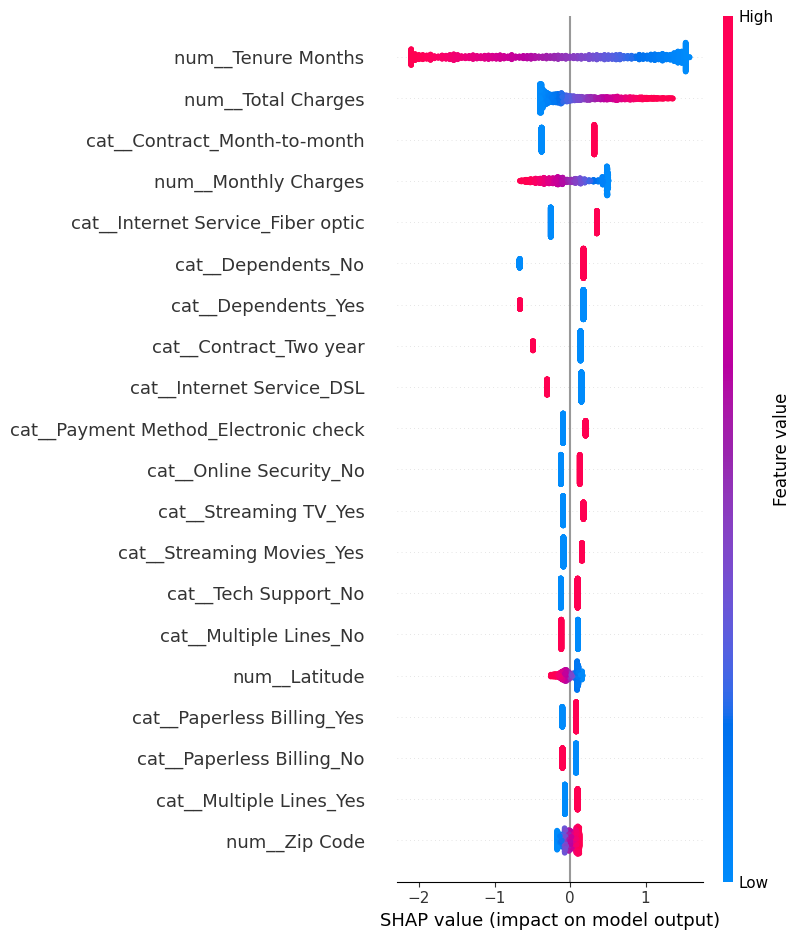

In [72]:
shap.summary_plot(
    shap_values.values,
    X_test_dense
)

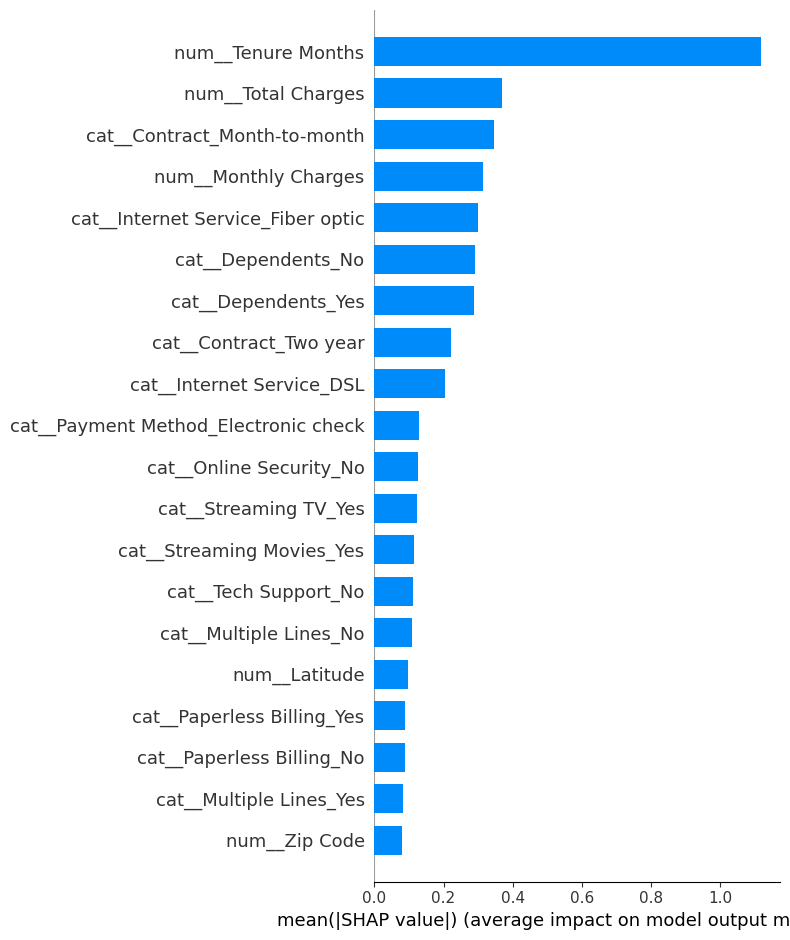

In [74]:
shap.summary_plot(
    shap_values.values,
    X_test_dense,
    plot_type="bar"
)

## Key Findings from SHAP Analysis

The SHAP analysis identified the most influential drivers of customer churn:

1. Customer tenure was the strongest predictor. Long-term customers were significantly less likely to churn.

2. Customers on month-to-month contracts exhibited a substantially higher churn probability compared to customers on annual contracts.

3. Higher monthly charges were associated with increased churn risk.

4. Fiber optic internet service showed a positive contribution to churn predictions.

5. Customers with longer customer lifetime value and longer service history were generally more likely to remain with the company.

These findings are consistent with the exploratory data analysis and provide interpretable business insights that could support customer retention strategies.

In [75]:
import joblib

joblib.dump(model, "../src/churn_model.pkl")

print("Model saved!")

Model saved!


In [76]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

joblib.dump(
    feature_names,
    "../src/feature_names.pkl"
)

['../src/feature_names.pkl']